# 01: Data Audit & Exploratory Analysis
**Project:** Eco-Commerce Recommender  
**Objective:** Clean the H&M dataset and identify initial sustainability signals in the `materials` column.

In [10]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style for charts
sns.set_theme(style="whitegrid")

In [11]:
# Load the data
df = pd.read_csv('../data/handm.csv')

# Initial check
print(f"Dataset Shape: {df.shape}")
print(df.columns)
df.head()

Dataset Shape: (9677, 16)
Index(['Unnamed: 0', 'productId', 'productName', 'brandName', 'url', 'price',
       'stockState', 'comingSoon', 'colorName', 'isOnline', 'colors',
       'colorShades', 'newArrival', 'mainCatCode', 'details', 'materials'],
      dtype='str')


,Unnamed: 0,productId,productName,brandName,url,price,stockState,comingSoon,colorName,isOnline,colors,colorShades,newArrival,mainCatCode,details,materials
0,0,834333001,Derby Shoes,H&M,https://www2.hm.com/en_us/productpage.08343330...,49.99,Available,False,Black,True,272628,Charcoal,False,men_shoes_dressed,Derby shoes with open lacing at front. Canvas ...,COMPOSITION\nSole:Thermoplastic rubber 100%\nU...
1,1,1258600003,Pile-Lined Slippers,H&M,https://www2.hm.com/en_us/productpage.12586000...,24.99,Available,False,Black,True,272628,Charcoal,False,men_shoes_slippers,Slippers in napped fabric. Decorative seam at ...,COMPOSITION\nLining:Polyester 100%\nUpper:Poly...
2,2,1036812001,Derby Shoes,H&M,https://www2.hm.com/en_us/productpage.10368120...,56.99,Available,False,Black,True,272628,Charcoal,False,men_shoes_dressed,Derby shoes in soft faux suede with open lacin...,COMPOSITION\nLining and insole:Cotton 100%\nUp...
3,3,1112924002,Fleece-lined Slippers,H&M,https://www2.hm.com/en_us/productpage.11129240...,29.99,Available,False,Dark blue,True,393B47,Bright blue|Cobalt blue|Dark blue|Indigo|Navy ...,False,men_shoes_slippers,Slippers in woven fabric with a moccasin seam ...,COMPOSITION\nLining:Polyester 100%\nUpper:Poly...
4,4,1119476020,Sneakers,H&M,https://www2.hm.com/en_us/productpage.11194760...,29.99,Available,False,White,True,FFFFFF,NaN,False,men_shoes_sneakers,"Sneakers with a padded upper edge and tongue, ...",COMPOSITION\nLining:Polyester 100%\nUpper:Poly...


Potential 'Green' products found: 261


/var/folders/1k/xv6jb5n94j7098g_bh_0h3nm0000gn/T/ipykernel_38172/295950427.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='is_green', data=df, palette='viridis')


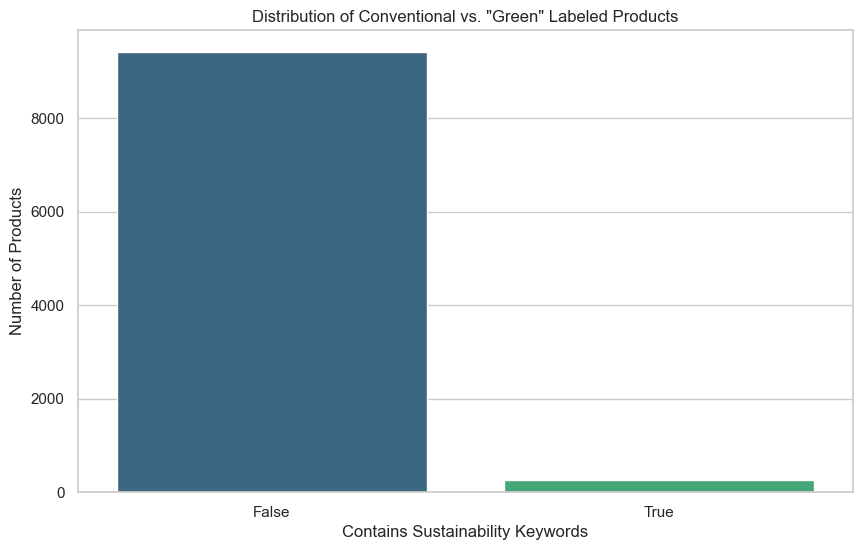

In [ ]:
green_keywords = ['recycled', 'organic', 'conscious', 'sustainable', 'eco', 'tencel', 'linen']

# Create a simple 'is_green' flag for visualization
df['is_green'] = df['productName'].str.contains('|'.join(green_keywords), case=False, na=False)

print(f"Potential 'Green' products found: {df['is_green'].sum()}")

# Plot the distribution
plt.figure(figsize=(10, 6))
sns.countplot(x='is_green', data=df, palette='viridis')
plt.title('Distribution of Conventional vs. "Green" Labeled Products')
plt.xlabel('Contains Sustainability Keywords')
plt.ylabel('Number of Products')
plt.show()

In [13]:
def extract_recycled_pct(text):
    if pd.isna(text): return 0
    match = re.search(r'(\d+)%\s*Recycled', str(text), re.IGNORECASE)
    return int(match.group(1)) if match else 0

# Apply to the materials column
df['recycled_pct'] = df['materials'].apply(extract_recycled_pct)

# Check results for high-recycled items
high_recycled = df[df['recycled_pct'] > 20]
print(f"Products with >20% recycled content: {len(high_recycled)}")
high_recycled[['productName', 'recycled_pct']].head()

Products with >20% recycled content: 4454


,productName,recycled_pct
0,Derby Shoes,37
1,Pile-Lined Slippers,26
3,Fleece-lined Slippers,63
6,Chelsea Boots,47
7,Chelsea Boots,44


### To quantify sustainability, I am moving beyond simple keyword matching and creating a weighted composite score that rewards specific recycled percentages and certifications while penalizing non-recyclable materials like sequins

### Phase 1: Basic Keyword Scoring (Initial Audit)

In [31]:
def calculate_sustainability_score(row):
    score = 0
    materials = str(row['materials']).lower()
    details = str(row['details']).lower()
    
    # 1. High-Value Material Bonus
    if 'recycled' in materials: score += 40
    if 'organic' in materials: score += 30
    if 'linen' in materials or 'hemp' in materials: score += 20
    if 'tencel' in materials or 'lyocell' in materials: score += 25
    
    # 2. Extract Specific Percentages
    pct_match = re.search(r'(\d+)%\s*recycled', materials)
    if pct_match:
        score += (int(pct_match.group(1)) / 2) 
        
    # 3. Certification Bonus
    certs = ['gots', 'fsc', 'grs', 'bci', 'tco']
    for cert in certs:
        if cert in details: score += 15
        
    # 4. Penalty for Harmful Materials
    if 'sequins' in materials or 'beads' in materials: score -= 10
    if 'polyurethane' in materials and 'recycled' not in materials: score -= 5
        
    return min(score, 100)

# Create the master score
df['sustainability_score'] = df.apply(calculate_sustainability_score, axis=1)

# Display top 10 most sustainable products
df[df['sustainability_score'] > 0][['productName', 'sustainability_score']].sort_values(by='sustainability_score', ascending=False).head(10)

,productName,sustainability_score
1004,Ribbed Henley Shirt,100.0
1254,Regular Fit Jersey Shirt,100.0
3680,Jacquard-Weave Bow-Front Dress,100.0
3805,Ribbed Pajamas,100.0
1281,Regular Fit Jersey Shirt,100.0
3014,MAMA Padded Microfiber Nursing Bra,100.0
2989,MAMA Padded Microfiber Nursing Bra,100.0
4627,Ribbed Pajamas,100.0
2597,Regular Fit Polo Shirt,100.0
5505,MAMA Padded Microfiber Nursing Bodysuit,100.0


In [32]:
# See how many products are in each category
print(df['mainCatCode'].value_counts())

# Use the exact string from your value_counts output
target_category = 'men_shirts_casual' 

# Filter for that category and a decent sustainability score
green_alternatives = df[(df['mainCatCode'] == target_category) & (df['sustainability_score'] > 30)]

print(f"Found {len(green_alternatives)} sustainable alternatives in '{target_category}'")

# Show the top 5
print(green_alternatives[['productName', 'sustainability_score']].sort_values(by='sustainability_score', ascending=False).head(5))

mainCatCode
ladies_cardigansjumpers_jumpers            361
men_shirts_casual                          250
ladies_dresses_shortdresses                170
ladies_tops_longsleeve                     164
ladies_tops_shortsleeve                    162
                                          ... 
ladies_divided_dresses                       1
sportswear_women_outerwear_jackets_rain      1
ladies_maternity_swimwear                    1
sportswear_women_activity_watersports        1
sportswear_women_clothing_tops_tanks         1
Name: count, Length: 355, dtype: int64
Found 126 sustainable alternatives in 'men_shirts_casual'
                     productName  sustainability_score
913   Regular Fit Sequined Shirt                  90.0
1022  Regular Fit Sequined Shirt                  90.0
1308           Regular Fit Shirt                  90.0
1302   Regular Fit Waffled Shirt                  90.0
1197           Regular Fit Shirt                  90.0


### Phase 2: Advanced Heuristic Scoring (Addressing Greenwashing & Expert Data)

In [44]:
import pandas as pd
import re

# 1. Load your expert dictionary
eco_dict = pd.read_csv('../data/scraped_materials.csv')['material_name'].tolist()

def final_refined_score(row):
    materials = str(row['materials']).lower()
    details = str(row['details']).lower()
    
    # 1. THE RECYCLED PLASTIC TIER (Score: 80)
    # It's better than virgin, but it's still plastic.
    if 'recycled polyester' in materials or 'recycled polyamide' in materials:
        score = 80
    
    # 2. THE NATURAL SUPERSTAR TIER (Score: 100)
    # Linen, Lyocell, and Organic Cotton are the 'Gold Standard'
    elif any(fiber in materials for fiber in ['linen', 'lyocell', 'tencel', 'hemp', 'organic cotton']):
        score = 100
    
    # 3. THE VIRGIN PLASTIC ZERO (Score: 0)
    elif ('polyester' in materials or 'polyamide' in materials) and 'recycled' not in materials:
        return 0.0
    
    # 4. DEFAULT
    else:
        score = 0
        
    # 5. CERTIFICATION BOOST (Max out at 100)
    if any(cert in details for cert in ['gots', 'grs', 'fsc']) and score > 0:
        score += 10

    return min(score, 100)

# Apply this final logic
df['sustainability_score'] = df.apply(final_refined_score, axis=1)

# Check the leaderboard
top_green = df[df['sustainability_score'] > 0].sort_values(by='sustainability_score', ascending=False)
top_green[['productName', 'sustainability_score', 'materials']].head(10)

df.to_csv('../data/handm_scored.csv', index=False)
print("✅ Dataset with sustainability scores saved successfully!")

df[df['sustainability_score'] > 0].sort_values(by='sustainability_score', ascending=False).head(10)

✅ Dataset with sustainability scores saved successfully!


,Unnamed: 0,productId,productName,brandName,url,price,stockState,comingSoon,colorName,isOnline,colors,colorShades,newArrival,mainCatCode,details,materials,is_green,recycled_pct,sustainability_score
2366,2366,1234387003,Regular Fit Linen-blend Shirt,H&M,https://www2.hm.com/en_us/productpage.12343870...,19.99,Available,False,Navy blue,True,1A2840,Bright blue|Cobalt blue|Dark blue|Indigo|Navy ...,False,men_shirts_casual,"Regular-fit, short-sleeved shirt in an airy co...","COMPOSITION\nLinen 52%, Cotton 48% , ADDITIONA...",True,20,100.0
6158,6158,941119011,10-pack Hipster Briefs,H&M,https://www2.hm.com/en_us/productpage.09411190...,29.99,Available,False,Light blue/light gray,True,BABFCC,Baby blue|Light blue|Sky blue,False,ladies_lingerie_briefsknickers_hipster,Hipster briefs in cotton-blend jersey. Mid-ris...,"COMPOSITION\nShell:Cotton 95%, Spandex 5%\nGus...",False,0,100.0
6154,6154,1226439005,Ribbed Tank Top,H&M,https://www2.hm.com/en_us/productpage.12264390...,6.99,Available,False,White/black striped,True,272628,NaN,False,ladies_basics_tops_vests,"Tank top in soft, ribbed cotton jersey. Scoop ...","COMPOSITION\nCotton 95%, Spandex 5% , ADDITION...",False,0,100.0
2345,2345,1212180001,Slim Fit Linen Shirt,H&M,https://www2.hm.com/en_us/productpage.12121800...,49.99,Available,False,White,True,FFFFFF,NaN,False,men_shirts_linenshirts,H&M Premium Selection\nSlim-fit shirt in airy ...,"COMPOSITION\nShell:Linen 100% , Material:\nLin...",True,0,100.0
2339,2339,1212180001,Slim Fit Linen Shirt,H&M,https://www2.hm.com/en_us/productpage.12121800...,49.99,Available,False,White,True,FFFFFF,NaN,False,men_shirts_linenshirts,H&M Premium Selection\nSlim-fit shirt in airy ...,"COMPOSITION\nShell:Linen 100% , Material:\nLin...",True,0,100.0
2327,2327,1212180002,Slim Fit Linen Shirt,H&M,https://www2.hm.com/en_us/productpage.12121800...,49.99,Available,False,Light blue,True,AFBFDF,Baby blue|Light blue|Pastel blue,False,men_shirts_linenshirts,H&M Premium Selection\nSlim-fit shirt in airy ...,"COMPOSITION\nShell:Linen 100% , Material:\nLin...",True,0,100.0
2287,2287,1257077002,Relaxed Fit Linen-Blend Pants,H&M,https://www2.hm.com/en_us/productpage.12570770...,39.99,Available,False,Navy blue,True,1A2840,Bright blue|Cobalt blue|Dark blue|Indigo|Navy ...,True,men_trousers_casual,"New Arrival\nRelaxed-fit pants in an airy, wov...","COMPOSITION\nShell:Cotton 60%, Linen 40%\nWais...",True,10,100.0
7863,7863,1202813002,Airy Resort Shirt,H&M,https://www2.hm.com/en_us/productpage.12028130...,17.99,Available,False,Light beige,True,D4D0C8,Ecru|Ivory|Taupe|Wheat,False,ladies_shirtsblouses_shirts,"Slightly longer, loose-fit shirt in an airy, w...","COMPOSITION\nRayon 83%, Linen 17% , ADDITIONAL...",False,0,100.0
7860,7860,1204900010,Oversized Linen Shirt,H&M,https://www2.hm.com/en_us/productpage.12049000...,34.99,Available,False,Light pink,True,E3B2C2,Baby pink|Dusty pink|Rose,False,ladies_shirtsblouses_shirts,"Oversized shirt in airy, woven linen fabric. C...","COMPOSITION\nLinen 100% , Material:\nLinen , M...",True,0,100.0
7850,7850,1235366012,Ribbed T-shirt,H&M,https://www2.hm.com/en_us/productpage.12353660...,7.99,Available,False,Light khaki green,True,A19D8E,Khaki green,False,ladies_basics_tops_shortsleeve,"Fitted T-shirt in soft, ribbed jersey with nar...","COMPOSITION\nShell:Cotton 95%, Spandex 5% , AD...",False,0,100.0
